# Train / Validation / Test — how to get an honest estimate of how good your model is

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · **▶ 07 Model Prep** · 08 Case Studies · 09 Deployment

`07_Model_Preparation/02_train_validation_test_splitting.ipynb`

---

### In one paragraph (no jargon)

A model's score on the data it learned from is meaningless — it has seen the answers. The fix is to hold some rows back. **Train** is what it learns from, **validation** is what you use to choose between options, and **test** is sealed until the very end and looked at exactly once. The reason for three rather than two: if you tune your model against the test set repeatedly, you've effectively trained on it, and your final number is optimistic again.

### After this notebook you can

- Split data into train/validation/test with `train_test_split`, applied twice
- Use `stratify=` to preserve class balance, and know when it's essential
- Split time-series data by date rather than randomly
- Use cross-validation for a more reliable estimate than a single split


### What's inside

1. Setup and the data
2. The simple two-way split
3. The three-way split
4. Stratified splitting
5. Verifying the split is balanced
6. ⚡ When a random split is the wrong answer
7. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Training set** | The rows the model learns from. Usually 60–80%. |
| **Validation set** | Rows used to choose between models and tune settings. You look at these many times. |
| **Test set** | Rows kept sealed until the very end, used once, to get an honest performance estimate. |
| **Overfitting** | The model memorised the training rows instead of learning the pattern. Great on train, poor on anything new. |
| **Data leakage** | Information from the test set influenced training, so your score is flattering and meaningless. |
| **Stratified split** | Splitting so each part keeps the same class balance as the whole — essential when one outcome is rare. |
| **Cross-validation** | Rotating which slice is held out, so every row is tested on exactly once. More reliable than a single split. |
| **random_state** | A fixed seed making the "random" split reproducible. Always set it. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_theme(style="whitegrid")
import tempfile
# WHY: exercises that SAVE a file write to a temp folder, so running this
#      notebook never scatters new files next to your notes.
EXPORT_DIR = tempfile.mkdtemp(prefix='bda_exports_')
print('Exports from this notebook will go to:', EXPORT_DIR)

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_demo():
    """Rebuild a dataset statistically equivalent to demo.csv (263 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 263
    frame = pd.DataFrame({
        'age': rng.normal(38.69, 13.45, n).clip(17, 90).round().astype(int),
        'workclass': rng.choice([' Private', ' Self-emp-not-inc', ' Local-gov', ' ?', ' State-gov', ' Federal-gov', ' Self-emp-inc'], n, p=[0.6844, 0.0722, 0.0684, 0.0532, 0.0494, 0.0418, 0.0306]),
        'fnlwgt': rng.normal(1.915e+05, 1.09e+05, n).clip(24215, 635913).round().astype(int),
        'eductation': rng.choice(['HS-grad', 'Some-college', 'Bachelors', 'Masters', '11th', 'Assoc-acdm', 'Assoc-voc', '7th-8th', '9th', 'Doctorate', '10th', 'Prof-school', '5th-6th', '1st-4th', 'Preschool'], n, p=[0.3118, 0.2167, 0.1635, 0.0608, 0.0456, 0.0456, 0.0418, 0.0228, 0.019, 0.019, 0.019, 0.0152, 0.0076, 0.0076, 0.004]),
        'education-num': rng.normal(10.15, 2.689, n).clip(1, 16).round().astype(int),
        'marital_status': rng.choice(['Married-civ-spouse', 'Never-married', 'Divorced', 'Separated', 'Widowed', 'Married-spouse-absent', 'Married-AF-spouse'], n, p=[0.4715, 0.3118, 0.1521, 0.0266, 0.0228, 0.0114, 0.0038]),
        'occupation': rng.choice(['Sales', 'Prof-specialty', 'Craft-repair', 'Exec-managerial', 'Other-service', 'Adm-clerical', 'Machine-op-inspct', '?', 'Handlers-cleaners', 'Tech-support', 'Transport-moving', 'Protective-serv', 'Farming-fishing'], n, p=[0.1331, 0.1293, 0.1217, 0.1179, 0.1179, 0.1103, 0.057, 0.0532, 0.0418, 0.0418, 0.0342, 0.0228, 0.019]),
        'relationship': rng.choice(['Husband', 'Not-in-family', 'Own-child', 'Unmarried', 'Wife', 'Other-relative'], n, p=[0.3992, 0.2738, 0.1521, 0.0837, 0.0608, 0.0304]),
        'race': rng.choice(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other'], n, p=[0.8061, 0.1369, 0.038, 0.0114, 0.0076]),
        'gender': rng.choice(['Male', 'Female'], n, p=[0.6768, 0.3232]),
        'capitol_gain': rng.normal(597.9, 3028, n).clip(0, 34095).round().astype(int),
        'capitol_loss': rng.normal(124.9, 465.7, n).clip(0, 2206).round().astype(int),
        'hrs_per_week': rng.normal(40.08, 11.28, n).clip(1, 80).round().astype(int),
        'native-country': rng.choice([' United-States', ' Mexico', ' ?', ' Cuba', ' Puerto-Rico', ' England', ' Iran', ' Jamaica', ' India', ' South', ' Honduras', ' Canada', ' Germany', ' Philippines', ' Italy', ' Poland', ' Columbia', ' Cambodia'], n, p=[0.8707, 0.0304, 0.0266, 0.0076, 0.0076, 0.0076, 0.0076, 0.0038, 0.0038, 0.0038, 0.0038, 0.0038, 0.0038, 0.0038, 0.0038, 0.0038, 0.0038, 0.0039]),
        'classifiaction_va': rng.choice([' <=50K', ' >50K'], n, p=[0.7681, 0.2319]),
    })
    return frame

def rebuild_train_validation_test_dataset():
    """Rebuild a dataset statistically equivalent to train_validation_test_dataset.xlsx (201 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 201
    frame = pd.DataFrame({
        'col_0': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Customer_ID', '1001', '1002', '1003', '1004', '1005'], n))],
        'col_1': [f"{v}_{i}" for i, v in enumerate(rng.choice(['45', '21', '49', '42', '56', '46'], n))],
        'col_2': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Income', '56224', '47464', '111778', '133889', '90487'], n))],
        'col_3': [f"{v}_{i}" for i, v in enumerate(rng.choice(['0', '12', '23', '25', '31', '8'], n))],
        'col_4': rng.choice(['Manager', 'Teacher', 'Engineer', 'Doctor', 'Analyst', 'Profession'], n, p=[0.2388, 0.2139, 0.199, 0.1891, 0.1542, 0.005]),
        'col_5': rng.choice(['Bengaluru', 'Goa', 'Chennai', 'Pune', 'Hyderabad', 'City'], n, p=[0.2388, 0.2139, 0.204, 0.1741, 0.1642, 0.005]),
        'col_6': rng.choice(['1', '0', 'Purchased'], n, p=[0.5572, 0.4378, 0.005]),
    })
    return frame

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Exports from this notebook will go to: /tmp/bda_exports_3b48cwuj
Setup complete. pandas 3.0.2 | numpy 2.4.4


# 02 · Train / Validation / Test Splitting
### Getting the split right is what makes every number after it trustworthy

There was no existing notebook for this topic — the original `Data_split`
folder held two datasets and a filename (`train_validation_test_dataset.xlsx`)
that made its intent obvious, but no code. This notebook builds that intent
out properly, on both datasets provided.

**Part A — `demo.csv`** (263 rows, adapted from the UCI Adult / Census
Income dataset): a small, **imbalanced** classification dataset — the case
where getting the split wrong actually shows up in the numbers.

**Part B — `train_validation_test_dataset.xlsx`** (200 rows, a customer
purchase dataset): the real three-way split the filename promises, done
correctly, verified, compared against a common mistake, and written back out
to a usable workbook.

**Learning objectives**
1. Why an unstratified split can quietly distort a small or imbalanced
   dataset — shown with real numbers, not just asserted.
2. The proportion-math mistake that's easy to make when chaining two splits
   into a three-way train/validation/test split.
3. Three ways to produce the same three-way split, compared.
4. When cross-validation (`KFold` / `StratifiedKFold`) is the better tool
   than any single static split.

**Contents**
- Part A: `demo.csv`
  1. Load & audit (including a pandas-3.0-specific gotcha)
  2. Clean
  3. Class balance
  4. Unstratified vs. stratified split, quantified
- Part B: `train_validation_test_dataset.xlsx`
  5. Load & audit
  6. The proportion-math trap
  7. Verifying the split
  8. Method showcase — three routes to the same three-way split
  9. Bonus: `KFold` vs `StratifiedKFold`
  10. Closing the loop — writing the split back to a workbook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

RANDOM_STATE = 42

---
# Part A · `demo.csv` — stratification matters more on small, imbalanced data

## 1 · Load & audit

In [3]:
demo = load_data('demo.csv', rebuild=rebuild_demo)
print(f"Shape: {demo.shape[0]} rows x {demo.shape[1]} columns")
demo.head()

Loaded 'demo.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: 263 rows x 15 columns


,age,workclass,fnlwgt,eductation,education-num,marital_status,occupation,relationship,race,gender,capitol_gain,capitol_loss,hrs_per_week,native-country,classifiaction_va
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# --- A pandas-3.0-specific trap worth knowing about ------------------------
# A very common idiom for finding "the text columns" checks dtype equality
# directly. On pandas 3.0, read_csv infers a dedicated `string` dtype
# instead of the old generic `object` dtype by default — and a direct
# equality check against `object` doesn't know that dtype exists at all.
direct_equality_check = [c for c in demo.columns if demo[c].dtype == object]
print(f"demo[c].dtype == object            finds: {direct_equality_check}")

demo[c].dtype == object            finds: []


In [5]:
# select_dtypes(include=['object']) looks like the safer, idiomatic version —
# and today, it still finds every text column. But look closely at what it
# says while doing it.
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    object_only = demo.select_dtypes(include=["object"]).columns.tolist()

print(f"select_dtypes(['object'])          finds: {object_only}")
print(f"...but raises: {caught[0].category.__name__ if caught else '(nothing)'}")

select_dtypes(['object'])          finds: ['workclass', 'eductation', 'marital_status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'classifiaction_va']
...but raises: Pandas4Warning


In [6]:
# The future-proof version: ask for BOTH dtypes explicitly, rather than
# leaning on a backward-compatibility shim the warning above says is being
# removed. No warning, and it keeps working once that shim is gone.
robust_text_cols = demo.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"select_dtypes(['object','string']) finds: {robust_text_cols}")

select_dtypes(['object','string']) finds: ['workclass', 'eductation', 'marital_status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'classifiaction_va']


Three checks, three outcomes: one finds nothing at all (silently — no error,
no warning, just an empty result that looks like "this dataset has no text
columns"), one works today but says outright it won't for much longer, and
one works cleanly either way. The middle one is exactly the kind of code
that passes review now and breaks in a library upgrade eighteen months from
now with no warning in the diff that introduced it.

In [7]:
# Now that we're actually looking at the right columns: how many hold the
# dataset's "?" missing-value placeholder (a convention from the original
# UCI source, not a pandas NaN)?
for col in robust_text_cols:
    n_placeholder = (demo[col].str.strip() == "?").sum()
    if n_placeholder:
        print(f"{col:16s} -> {n_placeholder} '?' placeholders")

workclass        -> 14 '?' placeholders
occupation       -> 14 '?' placeholders
native-country   -> 7 '?' placeholders


## 2 · Clean

Three small fixes: typo'd column names (`eductation`, `capitol_gain`,
`capitol_loss`), stray leading whitespace on every text value (a quirk of
the original source file's `", "` delimiter convention), and the `"?"`
placeholders converted to real, detectable `NaN`.

In [8]:
demo_clean = demo.rename(columns={
    "eductation": "education",
    "capitol_gain": "capital_gain",
    "capitol_loss": "capital_loss",
    "classifiaction_va": "income_class",
})

# Recompute the text-column list against the RENAMED frame — reusing the
# pre-rename `robust_text_cols` here would look up columns (like
# 'eductation') that no longer exist after the line above.
text_cols_clean = demo_clean.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols_clean:
    demo_clean[col] = demo_clean[col].str.strip()

demo_clean[text_cols_clean] = demo_clean[text_cols_clean].replace("?", np.nan)

print("Columns now:", demo_clean.columns.tolist())
print(f"\nMissing values introduced by the '?' -> NaN conversion:")
print(demo_clean.isnull().sum()[demo_clean.isnull().sum() > 0])

Columns now: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital_status', 'occupation', 'relationship', 'race', 'gender', 'capital_gain', 'capital_loss', 'hrs_per_week', 'native-country', 'income_class']

Missing values introduced by the '?' -> NaN conversion:
workclass         14
occupation        14
native-country     7
dtype: int64


## 3 · Class balance

The target — whether income is above or below $50K — is not close to
50/50. That imbalance is exactly what makes the next section's comparison
worth doing on *this* dataset instead of a synthetic, perfectly balanced one.

In [9]:
class_balance = demo_clean["income_class"].value_counts(normalize=True)
print(class_balance)

income_class
<=50K    0.768061
>50K     0.231939
Name: proportion, dtype: float64


## 4 · Unstratified vs. stratified split, quantified

`train_test_split` shuffles rows randomly by default. On a large dataset
that's harmless — the law of large numbers keeps the class ratio close to
the population's almost automatically. On 263 rows, it isn't automatic at
all.

In [10]:
X = demo_clean.drop(columns="income_class")
y = demo_clean["income_class"]

# --- Unstratified ------------------------------------------------------
# 🔧 CHANGE THIS: test_size is the fraction held out (0.2 = 20%).
# random_state fixes the shuffle so you get the same split every run — always set it.
# stratify=y keeps the class balance identical in each part — use it for classification.
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Stratified ----------------------------------------------------------
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

comparison = pd.DataFrame({
    "population":            class_balance,
    "unstratified — train":  y_train_u.value_counts(normalize=True),
    "unstratified — test":   y_test_u.value_counts(normalize=True),
    "stratified — train":    y_train_s.value_counts(normalize=True),
    "stratified — test":     y_test_s.value_counts(normalize=True),
}).round(3)
comparison

,population,unstratified — train,unstratified — test,stratified — train,stratified — test
income_class,,,,,
<=50K,0.768,0.79,0.679,0.767,0.774
>50K,0.232,0.21,0.321,0.233,0.226


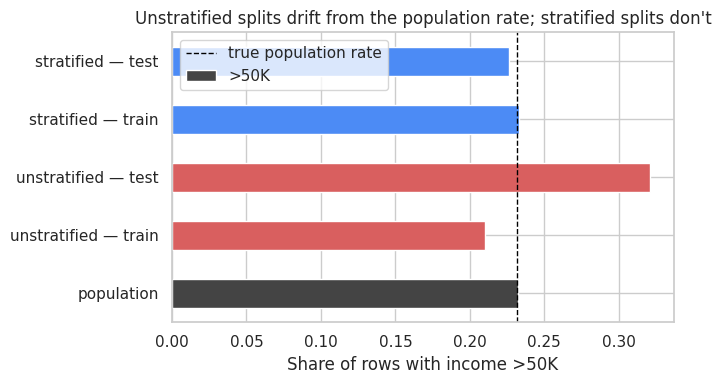

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
comparison.T[">50K"].plot(kind="barh", ax=ax, color=["#444444", "#d95f5f", "#d95f5f", "#4c8bf5", "#4c8bf5"])
ax.set_xlabel("Share of rows with income >50K")
ax.set_title("Unstratified splits drift from the population rate; stratified splits don't")
ax.axvline(class_balance[">50K"], color="black", linestyle="--", linewidth=1, label="true population rate")
ax.legend()
plt.tight_layout()
plt.show()

> The unstratified **test** split's `>50K` share visibly overshoots the true
> ~23% population rate in this run — nothing pathological, just what
> ordinary random chance does to a minority class on 263 rows. The
> stratified splits sit within a point or two of the true rate on both
> sides, every time, by construction rather than luck.

**Takeaway:** the smaller or more imbalanced the target, the more
`stratify=y` earns its place as a default, not an optional extra.

---
# Part B · `train_validation_test_dataset.xlsx` — the real three-way split

## 5 · Load & audit

In [12]:
customers = load_data('train_validation_test_dataset.xlsx', rebuild=rebuild_train_validation_test_dataset)
print(f"Shape: {customers.shape[0]} rows x {customers.shape[1]} columns")
print(f"Missing values: {customers.isnull().sum().sum()}   Duplicate rows: {customers.duplicated().sum()}")
customers.head()

Loaded 'train_validation_test_dataset.xlsx' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: 200 rows x 7 columns
Missing values: 0   Duplicate rows: 0


,Customer_ID,Age,Income,Experience,Profession,City,Purchased
0,1001,46,56224,19,Doctor,Bengaluru,0
1,1002,35,47464,11,Engineer,Chennai,0
2,1003,45,111778,23,Analyst,Bengaluru,1
3,1004,47,133889,23,Manager,Hyderabad,1
4,1005,34,90487,11,Teacher,Pune,0


In [13]:
purchase_rate = customers["Purchased"].value_counts(normalize=True)
print(purchase_rate)

Purchased
1    0.56
0    0.44
Name: proportion, dtype: float64


## 6 · The proportion-math trap

`train_test_split` only ever does a **two-way** split. Getting train /
validation / test out of it means calling it **twice** — carve off `test`
first, then split what's left into `train` and `validation`. The trap: the
second call's `test_size` is a fraction of the *remaining* data, not of the
original total. Naively reusing the same number both times quietly gives
you the wrong proportions.

In [14]:
X = customers.drop(columns="Purchased")
y = customers["Purchased"]
n = len(customers)

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9, "fractions must sum to 1"

In [15]:
# --- THE MISTAKE: reuse 0.15 directly on the remainder ----------------------
# 🔧 CHANGE THIS: test_size is the fraction held out (0.2 = 20%).
# random_state fixes the shuffle so you get the same split every run — always set it.
# stratify=y keeps the class balance identical in each part — use it for classification.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_FRAC, random_state=RANDOM_STATE, stratify=y
)
X_train_wrong, X_val_wrong, y_train_wrong, y_val_wrong = train_test_split(
    X_train_val, y_train_val, test_size=VAL_FRAC, random_state=RANDOM_STATE, stratify=y_train_val
)

print("Naive (wrong) proportions — reusing 0.15 directly on the remainder:")
for name, part in [("train", X_train_wrong), ("validation", X_val_wrong), ("test", X_test)]:
    print(f"  {name:11s}: {len(part):3d} rows ({len(part) / n:.1%} of total)")
print("Intended: train 70.0%, validation 15.0%, test 15.0%")

Naive (wrong) proportions — reusing 0.15 directly on the remainder:
  train      : 144 rows (72.0% of total)
  validation :  26 rows (13.0% of total)
  test       :  30 rows (15.0% of total)
Intended: train 70.0%, validation 15.0%, test 15.0%


In [16]:
# --- THE FIX: rescale the second test_size to the REMAINING data -----------
# We want validation to be 15% of the ORIGINAL total, but the second split
# only sees the 85% that's left after carving off test. So the second
# test_size is 15/85, not 15/100.
val_size_relative = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
print(f"Correct second-stage test_size = {VAL_FRAC} / ({TRAIN_FRAC} + {VAL_FRAC}) = {val_size_relative:.4f}")

# 🔧 CHANGE THIS: test_size is the fraction held out (0.2 = 20%).
# random_state fixes the shuffle so you get the same split every run — always set it.
# stratify=y keeps the class balance identical in each part — use it for classification.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size_relative,
    random_state=RANDOM_STATE, stratify=y_train_val
)

print("\nCorrect proportions:")
for name, part in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {name:11s}: {len(part):3d} rows ({len(part)/n:.1%} of total)")

Correct second-stage test_size = 0.15 / (0.7 + 0.15) = 0.1765

Correct proportions:
  train      : 139 rows (69.5% of total)
  validation :  31 rows (15.5% of total)
  test       :  30 rows (15.0% of total)


Two extra rows in validation, two fewer in train — small on 200 rows, but
the same bug on a larger dataset silently under-allocates an entire split by
a consistent, compounding amount. Worth getting right once, in one place.

## 7 · Verifying the split — sizes *and* class balance

Getting the row counts right isn't the whole job — `stratify=` at both
stages needs checking too, the same way Part A checked it.

In [17]:
summary = pd.DataFrame([
    {"split": "Train",      "rows": len(X_train), "pct_of_total": len(X_train) / n,
     "purchased_rate": y_train.mean()},
    {"split": "Validation", "rows": len(X_val),   "pct_of_total": len(X_val) / n,
     "purchased_rate": y_val.mean()},
    {"split": "Test",       "rows": len(X_test),  "pct_of_total": len(X_test) / n,
     "purchased_rate": y_test.mean()},
]).set_index("split")
summary["pct_of_total"] = (summary["pct_of_total"] * 100).round(1)
summary["purchased_rate"] = summary["purchased_rate"].round(3)
summary

,rows,pct_of_total,purchased_rate
split,,,
Train,139,69.5,0.561
Validation,31,15.5,0.548
Test,30,15.0,0.567


## 8 · Method showcase — three routes to the same three-way split

Same result, three implementations — useful to recognise all three, since
you'll meet each in different codebases.

In [18]:
# --- (1) Two sequential sklearn calls — what Sections 6-7 just did ---------
# Clearest, most common in practice; what the rest of this notebook uses.

# --- (2) Manual index shuffling ---------------------------------------------
# What train_test_split is doing internally, made explicit. Useful to see
# once so the library call stops feeling like a black box.
rng = np.random.default_rng(RANDOM_STATE)
shuffled_idx = rng.permutation(n)

n_train = int(TRAIN_FRAC * n)
n_val   = int(VAL_FRAC * n)

train_idx = shuffled_idx[:n_train]
val_idx   = shuffled_idx[n_train:n_train + n_val]
test_idx  = shuffled_idx[n_train + n_val:]

print(f"Manual shuffle split -> train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")
print("(This version does NOT stratify — it's here to show the mechanics, not to replace sklearn's call.)")

Manual shuffle split -> train=140, val=30, test=30
(This version does NOT stratify — it's here to show the mechanics, not to replace sklearn's call.)


In [19]:
# --- (3) One reusable, stratification-aware helper function ----------------
def three_way_split(X, y, train_frac=0.70, val_frac=0.15, test_frac=0.15,
                     random_state=None, stratify=True):
    '''Split X, y into train/validation/test with correctly-scaled
    proportions and consistent stratification at both stages.'''
    assert abs((train_frac + val_frac + test_frac) - 1.0) < 1e-9

    strat_1 = y if stratify else None
    # 🔧 CHANGE THIS: test_size is the fraction held out (0.2 = 20%).
    # random_state fixes the shuffle so you get the same split every run — always set it.
    # stratify=y keeps the class balance identical in each part — use it for classification.
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_frac, random_state=random_state, stratify=strat_1
    )

    strat_2 = y_trainval if stratify else None
    relative_val_size = val_frac / (train_frac + val_frac)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=relative_val_size,
        random_state=random_state, stratify=strat_2
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


X_train_fn, X_val_fn, X_test_fn, y_train_fn, y_val_fn, y_test_fn = three_way_split(
    X, y, random_state=RANDOM_STATE
)
print(f"Helper function -> train={len(X_train_fn)}, val={len(X_val_fn)}, test={len(X_test_fn)}")
print("Matches Section 6-7's manual two-call version:",
      X_train_fn.index.equals(X_train.index) and X_test_fn.index.equals(X_test.index))

Helper function -> train=139, val=31, test=30
Matches Section 6-7's manual two-call version: True


## 9 · Bonus: when a single split isn't enough — `KFold` vs `StratifiedKFold`

A single train/validation split gives one estimate of how well a model
generalises — and on 200 rows, that one estimate has real variance of its
own. **K-fold cross-validation** rotates which slice is held out *k* times
and averages the result, trading extra compute for a more stable estimate.
It's the standard choice for model selection and hyperparameter tuning on
small-to-medium data; a single static split remains the right call for the
*final*, never-touched-until-the-end test set, and for datasets large enough
that one split's variance is no longer a real concern.

In [20]:
kfold_rates, skfold_rates = [], []

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for _, val_idx in kf.split(X):
    kfold_rates.append(y.iloc[val_idx].mean())

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for _, val_idx in skf.split(X, y):
    skfold_rates.append(y.iloc[val_idx].mean())

fold_comparison = pd.DataFrame({
    "KFold (not stratified)": kfold_rates,
    "StratifiedKFold": skfold_rates,
}, index=[f"fold {i+1}" for i in range(5)])
fold_comparison

,KFold (not stratified),StratifiedKFold
fold 1,0.55,0.550
fold 2,0.50,0.550
fold 3,0.60,0.550
fold 4,0.65,0.575
fold 5,0.50,0.575


In [21]:
print(f"True population purchase rate: {y.mean():.3f}\n")
print(f"KFold per-fold spread            : {max(kfold_rates) - min(kfold_rates):.3f}")
print(f"StratifiedKFold per-fold spread  : {max(skfold_rates) - min(skfold_rates):.3f}")

True population purchase rate: 0.560

KFold per-fold spread            : 0.150
StratifiedKFold per-fold spread  : 0.025


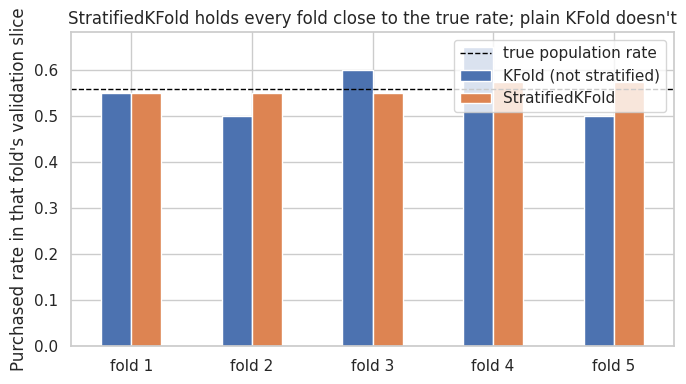

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
fold_comparison.plot(kind="bar", ax=ax)
ax.axhline(y.mean(), color="black", linestyle="--", linewidth=1, label="true population rate")
ax.set_ylabel("Purchased rate in that fold's validation slice")
ax.set_title("StratifiedKFold holds every fold close to the true rate; plain KFold doesn't")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10 · Closing the loop — writing the split back to a workbook

The source file arrived as a spreadsheet; the practical deliverable of a
splitting exercise is being able to hand each split to someone (or some
downstream script) as its own clean sheet — not leave it stranded inside a
notebook's variables.

In [23]:
import os
from openpyxl import load_workbook
from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
val_df   = pd.concat([X_val, y_val], axis=1).reset_index(drop=True)
test_df  = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

output_summary = summary.reset_index()

# WHY EXPORT_DIR: writing to a real ../outputs folder would scatter files next to
# your notes every time this notebook runs. EXPORT_DIR (set up in the setup cell)
# points to a temp folder instead, so running this notebook leaves your notes untouched.
output_dir = EXPORT_DIR
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "train_validation_test_SPLIT_RESULTS.xlsx")

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    output_summary.to_excel(writer, sheet_name="Summary", index=False)
    train_df.to_excel(writer, sheet_name="Train", index=False)
    val_df.to_excel(writer, sheet_name="Validation", index=False)
    test_df.to_excel(writer, sheet_name="Test", index=False)

# Light, consistent formatting: bold header row, frozen header, sane column widths
wb = load_workbook(output_path)
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    for cell in ws[1]:
        cell.font = Font(bold=True, name="Arial")
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.font = Font(name="Arial")
    ws.freeze_panes = "A2"
    for col_cells in ws.columns:
        width = max((len(str(c.value)) if c.value is not None else 0) for c in col_cells)
        ws.column_dimensions[get_column_letter(col_cells[0].column)].width = min(max(width + 2, 10), 30)
wb.save(output_path)

print(f"Wrote {output_path}")
for sheet_name, sheet_df in pd.read_excel(output_path, sheet_name=None).items():
    print(f"  {sheet_name:12s}: {sheet_df.shape}")

Wrote /tmp/bda_exports_3b48cwuj/train_validation_test_SPLIT_RESULTS.xlsx
  Summary     : (3, 4)
  Train       : (139, 7)
  Validation  : (31, 7)
  Test        : (30, 7)


### Recap

**Part A:** an unstratified split visibly skewed the minority class on a
263-row imbalanced dataset; a stratified split held both train and test
within a point or two of the true rate.

**Part B:** built the real three-way split the source filename promised —
caught and fixed the proportion-math mistake that comes from reusing a
fraction across two chained splits, verified both size *and* class balance,
compared three implementations of the same idea, showed `StratifiedKFold`
cutting per-fold variance roughly 6x versus plain `KFold`, and shipped the
result as a clean, ready-to-hand-off workbook.

**Where this feeds next:** `X_train` / `y_train` from Part B is exactly what
would go into `03_encoding_masterclass.ipynb`-style preprocessing from the
previous session — fit every encoder and scaler there, never on validation
or test data.

### ⚡ Beyond the syllabus — when a random split is the wrong answer

`train_test_split` shuffles rows at random, which is right for most cross-sectional data and **wrong** in three common situations. Recognising which situation you're in — and saying so — is worth more than any amount of tuning.

In [24]:
from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold,
                                     TimeSeriesSplit, GroupKFold, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rng = np.random.default_rng(42)

# ---- 1. TIME SERIES: never shuffle. Train on the past, test on the future. ----
dates = pd.date_range('2024-01-01', periods=365)
ts = pd.DataFrame({'date': dates,
                   'value': np.arange(365) * 0.5 + rng.normal(0, 5, 365)})
cutoff = ts['date'].quantile(0.8)
ts_train, ts_test = ts[ts['date'] <= cutoff], ts[ts['date'] > cutoff]
print("1. TIME SERIES")
print(f"   train: {ts_train['date'].min().date()} to {ts_train['date'].max().date()}  ({len(ts_train)} rows)")
print(f"   test : {ts_test['date'].min().date()} to {ts_test['date'].max().date()}  ({len(ts_test)} rows)")
print("   WHY: a random split would train on December and test on March — predicting")
print("        the past from the future. The score would be meaningless.\n")

# ---- 2. IMBALANCED CLASSES: stratify, or a rare class can vanish -------------
n = 1000
imbalanced = pd.DataFrame({'x': rng.normal(0, 1, n)})
imbalanced['y'] = (rng.random(n) < 0.03).astype(int)          # only 3% positives
plain_tr, plain_te = train_test_split(imbalanced, test_size=.2, random_state=0)
strat_tr, strat_te = train_test_split(imbalanced, test_size=.2, random_state=0,
                                      stratify=imbalanced['y'])
print("2. IMBALANCED CLASSES  (3% positive)")
print(f"   whole dataset   : {imbalanced['y'].mean():.3%} positive")
print(f"   plain split test: {plain_te['y'].mean():.3%} positive  ({plain_te['y'].sum()} cases)")
print(f"   stratified test : {strat_te['y'].mean():.3%} positive  ({strat_te['y'].sum()} cases)")
print("   WHY: without stratify the rare class can be badly under-represented, or absent.\n")

# ---- 3. GROUPED DATA: keep all rows of an entity on the same side -------------
groups = np.repeat(np.arange(100), 10)                        # 100 patients, 10 visits each
grouped = pd.DataFrame({'patient': groups,
                        'x': rng.normal(0, 1, 1000),
                        'y': rng.integers(0, 2, 1000)})
gkf = GroupKFold(n_splits=5)
tr_idx, te_idx = next(gkf.split(grouped, grouped['y'], groups=grouped['patient']))
shared = set(grouped.iloc[tr_idx]['patient']) & set(grouped.iloc[te_idx]['patient'])
print("3. GROUPED / REPEATED MEASURES")
print(f"   patients appearing in both train and test with GroupKFold: {len(shared)}")
print("   WHY: a random split puts visits 1-7 of a patient in train and 8-10 in test.")
print("        The model recognises the patient rather than learning the condition.\n")

# ---- Cross-validation: more reliable than any single split -------------------
X, y = imbalanced[['x']], imbalanced['y']
single = train_test_split(imbalanced, test_size=.2, random_state=0, stratify=y)
cv_scores = cross_val_score(LogisticRegression(), X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print("4. CROSS-VALIDATION")
print(f"   5-fold AUC scores : {np.round(cv_scores, 4)}")
print(f"   mean +/- sd       : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print("   WHY: a single split gives one number with no sense of how much it would move")
print("        if you'd shuffled differently. The spread here IS that uncertainty.")

print("""
CHOOSING THE SPLIT
  ordinary cross-sectional data  ->  train_test_split(random_state=42)
  classification, any imbalance  ->  add stratify=y
  anything with a time dimension ->  split by date; TimeSeriesSplit for CV
  repeated measures per entity   ->  GroupKFold on the entity ID
  small dataset                  ->  cross-validation rather than one split""")

1. TIME SERIES
   train: 2024-01-01 to 2024-10-18  (292 rows)
   test : 2024-10-19 to 2024-12-30  (73 rows)
   WHY: a random split would train on December and test on March — predicting
        the past from the future. The score would be meaningless.

2. IMBALANCED CLASSES  (3% positive)
   whole dataset   : 2.100% positive
   plain split test: 1.500% positive  (3 cases)
   stratified test : 2.000% positive  (4 cases)
   WHY: without stratify the rare class can be badly under-represented, or absent.

3. GROUPED / REPEATED MEASURES
   patients appearing in both train and test with GroupKFold: 0
   WHY: a random split puts visits 1-7 of a patient in train and 8-10 in test.
        The model recognises the patient rather than learning the condition.

4. CROSS-VALIDATION
   5-fold AUC scores : [0.6033 0.5357 0.4643 0.6263 0.5405]
   mean +/- sd       : 0.5540 +/- 0.0570
   WHY: a single split gives one number with no sense of how much it would move
        if you'd shuffled differently. T

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Two-way split | `train_test_split(X, y, test_size=0.2, random_state=42)` |
| Three-way split | split once, then split the training part again |
| Keep class balance | `stratify=y` |
| Reproducible | `random_state=42` |
| Split a whole frame | `train_test_split(df, test_size=0.2)` |
| Check the proportions | `y_train.value_counts(normalize=True)` |
| Cross-validation | `cross_val_score(model, X, y, cv=5)` |
| Stratified CV | `cv=StratifiedKFold(5)` |
| Time-series CV | `cv=TimeSeriesSplit(5)` |
| Grouped CV | `GroupKFold(5).split(X, y, groups=ids)` |
| Split by date | `df[df.date <= cutoff]`, `df[df.date > cutoff]` |

### Adapting this in the exam

- 'Split the data into training and testing' → `train_test_split` with `test_size` and `random_state`, then print both shapes.
- 'Ensure the classes are balanced in both sets' → `stratify=y`, then show `value_counts(normalize=True)` for each.
- 'This is monthly sales data' → split by date, and say why a random split would be invalid.

### Traps that cost marks

- No `random_state` means a different split every run, so your results aren't reproducible — and an examiner can't match your numbers.
- Without `stratify=y`, a rare class can be under-represented or missing entirely from the test set.
- Never shuffle time-series data. Split by date or you're predicting the past from the future.
- Fit scalers, imputers and encoders on **train only**, then `transform` the others.
- Looking at the test set repeatedly while tuning turns it into a validation set. That's what the third split is for.
- For a 60/20/20 split, the second call needs `test_size=0.25` (25% of the remaining 80% = 20% of the original).